In [1]:
# libraries
import os
import copy
import pickle
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, fbeta_score

import seaborn as sns
import matplotlib.pyplot as plt

from pythonfn_prepInput_v3_1 import readInProfiles 
from pythonfn_prepInput_v3_1 import readInMetadata
from pythonfn_prepInput_v3_1 import generateModelInput

seed = 0
np.random.seed(seed)

In [2]:
dir_ = "/projects/ralab/data/projects/nucleiCAGEproject/5.EPCrisprBenchmark/"

In [3]:
#### IMPORTS, SETUP, AND MANAGE DF ####

In [4]:
# 0. import profiles

remove_word = ['Cap_align', 'pcr_align', 'C.csv', 'N.csv', 'N_10M', 'ProCap_pcr_1']

pos_prfl = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles_subtnorm/pos/", setName="EPC-pos profiles", withoutWord=remove_word)
pos_prfl.reset_index(inplace=True, drop=True)

neg_prfl = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles_subtnorm/neg/", setName="EPC-neg profiles", withoutWord=remove_word)
neg_prfl.reset_index(inplace=True, drop=True)

pos_count = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles/pos/", setName="EPC-pos counts", withoutWord=remove_word)
neg_count = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles/neg/", setName="EPC-neg counts", withoutWord=remove_word)

EPC-pos profiles
profiles_pos.K562_10M_N1.csv contains 429 rows
profiles_pos.K562_10M_N2.csv contains 429 rows
profiles_pos.K562_10M_N3.csv contains 429 rows
profiles_pos.K562_C1.csv contains 429 rows
profiles_pos.K562_C2.csv contains 429 rows
profiles_pos.K562_C3.csv contains 429 rows
profiles_pos.K562_N4.csv contains 429 rows
profiles_pos.K562_N5.csv contains 429 rows
profiles_pos.K562_N6.csv contains 429 rows
profiles_pos.K562_ProCap_pcr_2.csv contains 429 rows
profiles_pos.K562_groCap_1.csv contains 429 rows
In total, the dataset contains 4719 rows 

EPC-neg profiles
profiles_neg.K562_10M_N1.csv contains 3448 rows
profiles_neg.K562_10M_N2.csv contains 3448 rows
profiles_neg.K562_10M_N3.csv contains 3448 rows
profiles_neg.K562_C1.csv contains 3448 rows
profiles_neg.K562_C2.csv contains 3448 rows
profiles_neg.K562_C3.csv contains 3448 rows
profiles_neg.K562_N4.csv contains 3448 rows
profiles_neg.K562_N5.csv contains 3448 rows
profiles_neg.K562_N6.csv contains 3448 rows
profiles_neg.K

In [5]:
# make sure that it's the same order as count input data
prfl_order = ['10MN1', '10MN2', '10MN3', 'C1', 'C2', 'C3', 
              'N4', 'N5', 'N6', 'PC2', 'GC1']

In [6]:
# 1. import EPC position info .csv
pos_csv = pd.read_csv(dir_ + "1.EPC.DHS.eQTL.pos.csv")
pos_csv = pos_csv.drop(pos_csv.columns[0], axis=1)
neg_csv = pd.read_csv(dir_ + "1.EPC.DHS.eQTL.neg.csv")
neg_csv = neg_csv.drop(neg_csv.columns[0], axis=1)

In [7]:
# 2. count 

In [8]:
def countsum(csv_, count_, countsumcol_):
    newcount = copy.deepcopy(count_)
    newcsv = copy.deepcopy(csv_)
    
    newcount['RowSums'] = newcount.sum(axis=1)
    ls = []
    for i in range(len(newcsv)):
        ls.append(list(newcount.loc[i]['RowSums']))

    ls_df = pd.DataFrame(ls, columns=countsumcol_)
    newcsv['countsum_all'] = ls_df.sum(axis=1)
    return(newcsv, ls_df)

In [9]:
# countsum 
pos_csv, pos_countsum = countsum(pos_csv, pos_count, prfl_order)
neg_csv, neg_countsum = countsum(neg_csv, neg_count, prfl_order)

In [10]:
# 3. yproba

In [11]:
# load models
filename = 'model_Meena_v2_fullModel_all.sav'
model = pickle.load(open(filename, 'rb'))

In [12]:
pos_prfl_np = pos_prfl.to_numpy()
neg_prfl_np = neg_prfl.to_numpy()

In [13]:
# prediction
y_proba_pos = model.predict_proba(pos_prfl_np)
y_proba_neg = model.predict_proba(neg_prfl_np)

In [14]:
# create probability df
def proba(csv, y_proba, y_proba_col): 
    loop_ls = list(range(0, len(y_proba)+1, len(csv)))
    df = pd.DataFrame()
    for i in range(len(y_proba_col)):
        tmp = y_proba[(loop_ls[i]):(loop_ls[i+1]), 1]
        df[y_proba_col[i]] = tmp
    return(df)

In [15]:
# yproba
pos_yproba = proba(pos_csv, y_proba_pos, prfl_order)
neg_yproba = proba(neg_csv, y_proba_neg, prfl_order)

In [16]:
# masking values in yproba df based on conditions in countsum df
pos_mask = pos_countsum <= 1
neg_mask = neg_countsum <= 1

In [17]:
# masked yproba to nan
pos_yproba_masknan = pos_yproba.where(~pos_mask, np.nan)
neg_yproba_masknan = neg_yproba.where(~neg_mask, np.nan)

In [18]:
yproba_masknan = pd.concat([pos_yproba_masknan, neg_yproba_masknan], ignore_index=True)

In [19]:
# masked yproba to -1
pos_yproba_maskm1 = pos_yproba.where(~pos_mask, -1)
neg_yproba_maskm1 = neg_yproba.where(~neg_mask, -1)

In [20]:
yproba_maskm1 = pd.concat([pos_yproba_maskm1, neg_yproba_maskm1], ignore_index=True)

In [21]:
# 4. dl

In [22]:
# import DLs .csv
pos_dl = pd.read_csv(dir_ + "3.pos.DLrepSub.csv")
neg_dl = pd.read_csv(dir_ + "3.neg.DLrepSub.csv")

In [23]:
prfl_absdir = {'absdir.K562_C1':'absdir.C1', 'absdir.K562_C2':'absdir.C2', 'absdir.K562_C3':'absdir.C3',
               'absdir.K562_N4':'absdir.N4', 'absdir.K562_N5':'absdir.N5', 'absdir.K562_N6':'absdir.N6',
               'absdir.K562_groCap_1':'absdir.GC1', 'absdir.K562_ProCap_pcr_2':'absdir.PC2',
               'absdir.K562_10M_N1':'absdir.10MN1', 'absdir.K562_10M_N2':'absdir.10MN2', 'absdir.K562_10M_N3':'absdir.10MN3',
               'score.K562_C1':'score.C1', 'score.K562_C2':'score.C2', 'score.K562_C3':'score.C3',
               'score.K562_N4':'score.N4', 'score.K562_N5':'score.N5', 'score.K562_N6':'score.N6',
               'score.K562_groCap_1':'score.GC1', 'score.K562_ProCap_pcr_2':'score.PC2',
               'score.K562_10M_N1':'score.10MN1', 'score.K562_10M_N2':'score.10MN2', 'score.K562_10M_N3':'score.10MN3'}

In [24]:
columns_to_drop = ['absdir.K562_C', 'score.K562_C', 
                   'absdir.K562_N', 'score.K562_N', 
                   'absdir.K562_ProCap_pcr_1', 'score.K562_ProCap_pcr_1', 
                   'absdir.K562_N_10M', 'score.K562_N_10M',
                   'absdir.K562_Cap_align', 'score.K562_Cap_align', 'absdir.K562_pcr_align', 'score.K562_pcr_align']

In [25]:
# drop rowname column, rename column names, reorder column for POSITIVE
pos_dl = pos_dl.drop(pos_dl.columns[0], axis=1)
pos_dl = pos_dl.drop(columns=columns_to_drop, axis=1)
pos_dl = pos_dl.rename(columns=prfl_absdir)
#pos_dl = pos_dl[prfl_order]

# drop rowname column, rename column names, reorder column for NEGATIVE
neg_dl = neg_dl.drop(neg_dl.columns[0], axis=1)
neg_dl = neg_dl.drop(columns=columns_to_drop, axis=1)
neg_dl = neg_dl.rename(columns=prfl_absdir)
#neg_dl = neg_dl[prfl_order]

In [26]:
neg_dl

,absdir.C1,score.C1,absdir.C2,score.C2,absdir.C3,score.C3,absdir.N4,score.N4,absdir.N5,score.N5,...,absdir.GC1,score.GC1,absdir.PC2,score.PC2,absdir.10MN1,score.10MN1,absdir.10MN2,score.10MN2,absdir.10MN3,score.10MN3
0,NaN,NaN,NaN,NaN,0.714286,7.0,0.333333,15.0,NaN,NaN,...,0.578947,19.0,0.152877,1825.0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,6.0,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,0.920680,353.0,NaN,NaN,...,0.142857,7.0,NaN,NaN,NaN,NaN,0.955947,227.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,0.411765,34.0,NaN,NaN,...,0.500000,4.0,NaN,NaN,NaN,NaN,0.111111,9.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.500000,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3444,0.600000,5.0,NaN,NaN,0.994004,6671.0,0.333333,3.0,0.500000,8.0,...,0.142857,7.0,NaN,NaN,0.361854,11781.0,0.333333,3.0,NaN,NaN
3445,0.833333,12.0,0.95977,348.0,NaN,NaN,0.887850,107.0,0.998074,8309.0,...,0.600000,5.0,NaN,NaN,0.000000,4.0,0.818182,11.0,NaN,NaN
3446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
pos_dl_score = pos_dl.filter(like='score')
pos_dl_score.columns = pos_dl_score.columns.str.replace('score.', '')

neg_dl_score = neg_dl.filter(like='score')
neg_dl_score.columns = neg_dl_score.columns.str.replace('score.', '')

/tmp/ipykernel_3963819/1109824167.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  pos_dl_score.columns = pos_dl_score.columns.str.replace('score.', '')
/tmp/ipykernel_3963819/1109824167.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  neg_dl_score.columns = neg_dl_score.columns.str.replace('score.', '')


In [28]:
pos_dl_score

,C1,C2,C3,N4,N5,N6,GC1,PC2,10MN1,10MN2,10MN3
0,23.0,23.0,4.0,6.0,4.0,1888.0,NaN,29.0,47.0,5.0,7023.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,65.0,3.0,52.0,522.0,25.0,7.0,5.0,7.0,421.0,953.0,NaN
3,9.0,5.0,NaN,9.0,188.0,4.0,576.0,1177.0,NaN,6.0,4.0
4,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,5.0,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
424,NaN,9.0,3.0,1642.0,19.0,12.0,9.0,NaN,28.0,26.0,NaN
425,4.0,NaN,NaN,19.0,NaN,NaN,1353.0,NaN,NaN,4.0,NaN
426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
pos_dl_absdir = pos_dl.filter(like='absdir')
pos_dl_absdir.columns = pos_dl_absdir.columns.str.replace('absdir.', '')

neg_dl_absdir = neg_dl.filter(like='absdir')
neg_dl_absdir.columns = neg_dl_absdir.columns.str.replace('absdir.', '')

/tmp/ipykernel_3963819/473728915.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  pos_dl_absdir.columns = pos_dl_absdir.columns.str.replace('absdir.', '')
/tmp/ipykernel_3963819/473728915.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  neg_dl_absdir.columns = neg_dl_absdir.columns.str.replace('absdir.', '')


In [30]:
neg_dl_absdir

,C1,C2,C3,N4,N5,N6,GC1,PC2,10MN1,10MN2,10MN3
0,NaN,NaN,0.714286,0.333333,NaN,0.333333,0.578947,0.152877,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,NaN
3,NaN,NaN,NaN,0.920680,NaN,NaN,0.142857,NaN,NaN,0.955947,NaN
4,NaN,NaN,NaN,0.411765,NaN,0.333333,0.500000,NaN,NaN,0.111111,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3443,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN
3444,0.600000,NaN,0.994004,0.333333,0.500000,NaN,0.142857,NaN,0.361854,0.333333,NaN
3445,0.833333,0.95977,NaN,0.887850,0.998074,NaN,0.600000,NaN,0.000000,0.818182,NaN
3446,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN


In [31]:
dl_score = pd.concat([pos_dl_score, neg_dl_score], ignore_index=True)
dl_absdir = pd.concat([pos_dl_absdir, neg_dl_absdir], ignore_index=True)

In [32]:
# DLs mask with 1.1 # because 0s are in positive range
pos_dl_absdir_mask1 = pos_dl_absdir.fillna(1.1)
neg_dl_absdir_mask1 = neg_dl_absdir.fillna(1.1)

In [33]:
dl_absdir_mask1 = pd.concat([pos_dl_absdir_mask1, neg_dl_absdir_mask1], ignore_index=True)

In [34]:
#### OBJECTS ####

In [35]:
# csv
pos_csv
neg_csv

,seqnames,start,end,width,strand,thick,measuredGeneSymbol,Regulated,EffectSize,Significant,pValueAdjusted,txType,count.DHS,ovl.DHS,count.eQTL.neg0.01,count.eQTL.pos0.5,count.eQTL.pos0.9,ovl.eQTL0.5,ovl.eQTL0.9,countsum_all
0,chr1,3804460,3804960,501,*,3804710,LRRC47;SMIM1,False,-0.001471265;0.025676924,False,0.999918431;0.994159681,intergenic,1,True,0,0,0,NaN,NaN,418
1,chr1,4126791,4127291,501,*,4127041,SMIM1,False,0.023383787,False,0.992197132,intergenic,0,False,0,0,0,NaN,NaN,1
2,chr1,5304578,5305078,501,*,5304828,RPL22,False,0.026721884,False,0.990078871,exon,1,True,0,0,0,NaN,NaN,7
3,chr1,8197596,8198096,501,*,8197846,PARK7,False,-0.019877177,False,0.955905753,intergenic,1,True,0,0,0,NaN,NaN,112
4,chr1,8899850,8900350,501,*,8900100,PARK7,False,-0.041882396,False,0.959632967,intergenic,2,True,0,0,0,NaN,NaN,184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3443,chrX,153853584,153854084,501,*,153853834,RPL10;EMD,False,0.046676354;0.015914761,False,0.86454388;0.995871246,intergenic,1,True,0,0,0,NaN,NaN,42
3444,chrX,154001821,154002321,501,*,154002071,SSR4;RPL10;BCAP31;MPP1;NAA10,False,-0.02168079;0.045933076;-0.060520994;0.0418509...,False,0.999918431;0.807012018;0.529512039;0.73780767...,intergenic,2,True,0,0,0,NaN,NaN,145
3445,chrX,154527069,154527569,501,*,154527319,RPL10;EMD;MPP1;NAA10;FAM3A;FUNDC2;LAGE3;UBL4A,False,0.037956142;0.022522793;0.069823805;-0.0174043...,False,0.869663193;0.999918431;0.251099642;0.816804378,intron,2,True,0,0,0,NaN,NaN,624
3446,chrX,154757390,154757890,501,*,154757640,RPL10;MPP1;NAA10,False,0.021206189;0.056091012;-0.02297122,False,0.999918431;0.914790463,intergenic,2,True,0,0,0,NaN,NaN,12


In [36]:
# make sure that it's the same order as count input data
prefer_order = ['C1', 'C2', 'C3', 
                'N4', 'N5', 'N6',
                '10MN1', '10MN2', '10MN3', 
                'GC1', 'PC2']

In [37]:
# countsum
pos_countsum = pos_countsum[prefer_order]
neg_countsum = neg_countsum[prefer_order]

pos_mask = pos_mask[prefer_order]
neg_mask = neg_mask[prefer_order]

In [38]:
# yproba
pos_yproba_masknan = pos_yproba_masknan[prefer_order]
neg_yproba_masknan = neg_yproba_masknan[prefer_order]
yproba_masknan = yproba_masknan[prefer_order]

pos_yproba_maskm1 = pos_yproba_maskm1[prefer_order]
neg_yproba_maskm1 = neg_yproba_maskm1[prefer_order]
yproba_maskm1 = yproba_maskm1[prefer_order]

In [39]:
# dl
pos_dl_score = pos_dl_score[prefer_order]
neg_dl_score = neg_dl_score[prefer_order]
dl_score = dl_score[prefer_order]

pos_dl_absdir = pos_dl_absdir[prefer_order]
neg_dl_absdir = neg_dl_absdir[prefer_order]
dl_absdir = dl_absdir[prefer_order]

pos_dl_absdir_mask1 = pos_dl_absdir_mask1[prefer_order]
neg_dl_absdir_mask1 = neg_dl_absdir_mask1[prefer_order]
dl_absdir_mask1 = dl_absdir_mask1[prefer_order]

In [40]:
dl_score

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
0,23.0,23.0,4.0,6.0,4.0,1888.0,47.0,5.0,7023.0,NaN,29.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
2,65.0,3.0,52.0,522.0,25.0,7.0,421.0,953.0,NaN,5.0,7.0
3,9.0,5.0,NaN,9.0,188.0,4.0,NaN,6.0,4.0,576.0,1177.0
4,NaN,NaN,NaN,NaN,NaN,NaN,5.0,6.0,NaN,9.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
3873,5.0,NaN,6671.0,3.0,8.0,NaN,11781.0,3.0,NaN,7.0,NaN
3874,12.0,348.0,NaN,107.0,8309.0,NaN,4.0,11.0,NaN,5.0,NaN
3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN


In [41]:
# save info
pos_csv.to_csv('4.1.pos.info.repSub.csv', index=False)
neg_csv.to_csv('4.1.neg.info.repSub.csv', index=False)

# save count
pos_countsum.to_csv('4.2.pos.count.repSub.csv', index=False)
neg_countsum.to_csv('4.2.neg.count.repSub.csv', index=False)

# save yproba
pos_yproba_masknan.to_csv('4.3.pos.proba.repSub.csv', index=False)
neg_yproba_masknan.to_csv('4.3.neg.proba.repSub.csv', index=False)

# save directionality
pos_dl_score.to_csv('4.4.pos.DLscore.repSub.csv', index=False)
neg_dl_score.to_csv('4.4.neg.DLscore.repSub.csv', index=False)

pos_dl_absdir.to_csv('4.4.pos.abs.directionality.repSub.csv', index=False)
neg_dl_absdir.to_csv('4.4.neg.abs.directionality.repSub.csv', index=False)

In [42]:
pos_yproba_TP_FN = pos_yproba_maskm1.applymap(lambda x: 'TP' if x >= 0.5 else 'FN')
neg_yproba_TN_FP = neg_yproba_maskm1.applymap(lambda x: 'TN' if x < 0.5 else 'FP')

pos_yproba_TP_FN.to_csv('4.5.pos_TP_FN.repSub.csv', index=False)
neg_yproba_TN_FP.to_csv('4.5.neg_TN_FP.repSub.csv', index=False)

In [43]:
countSum_plt = pd.concat([pos_countsum, neg_countsum], ignore_index=True)
countSum_plt

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
0,23,9,7,38,32,37,11,7,17,480,225
1,0,0,0,2,0,0,0,4,1,44,26
2,65,60,65,253,245,282,30,22,29,910,73
3,9,24,22,48,51,58,14,16,22,491,248
4,5,4,0,20,21,23,11,10,10,204,141
...,...,...,...,...,...,...,...,...,...,...,...
3872,0,0,0,3,1,0,0,2,3,15,18
3873,1,4,4,11,2,6,4,2,10,58,43
3874,12,11,15,19,28,31,6,5,2,284,211
3875,0,0,0,0,0,0,0,0,0,11,1


In [44]:
tnfntpfp_plt = pd.concat([pos_yproba_TP_FN, neg_yproba_TN_FP], )
tnfntpfp_plt

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
0,TP,TP,TP,TP,TP,TP,TP,TP,TP,TP,TP
1,FN,FN,FN,FN,FN,FN,FN,TP,FN,TP,TP
2,TP,TP,TP,TP,TP,TP,TP,TP,TP,TP,TP
3,TP,TP,TP,TP,TP,TP,TP,TP,TP,TP,TP
4,TP,FN,FN,FN,TP,FN,TP,TP,TP,TP,TP
...,...,...,...,...,...,...,...,...,...,...,...
3443,TN,TN,TN,FP,TN,TN,TN,TN,TN,FP,FP
3444,TN,TN,TN,FP,TN,FP,FP,FP,FP,FP,FP
3445,FP,FP,FP,FP,FP,FP,FP,FP,FP,FP,FP
3446,TN,TN,TN,TN,TN,TN,TN,TN,TN,FP,TN


In [45]:
df1 = tnfntpfp_plt
df2 = countSum_plt

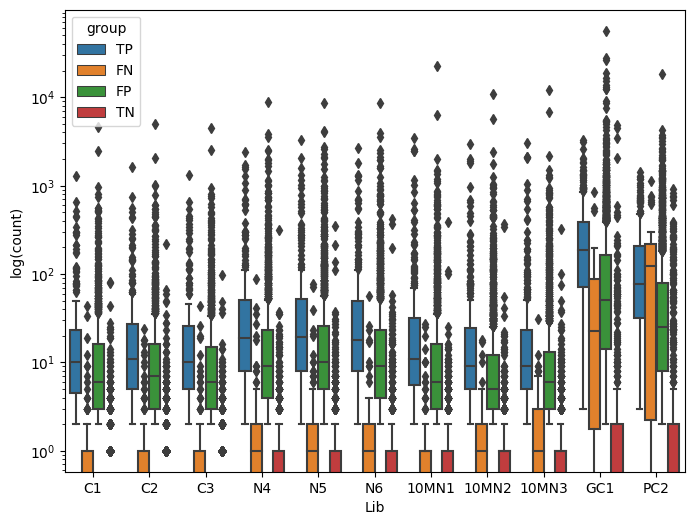

In [46]:
alldf = pd.DataFrame()
for i in df2.columns:
    df_lib = pd.DataFrame([i]*len(df2))
    df_plot = pd.concat([df2[i].reset_index(drop=True), df1[i].reset_index(drop=True), df_lib], axis=1)
    df_plot.columns = ['count', 'group', 'lib']
    alldf = pd.concat([alldf, df_plot], axis=0, ignore_index=True)
    
plt.figure(figsize=(8, 6))
sns.boxplot(data=alldf, x='lib', y='count', hue='group')
plt.title('')
plt.xlabel('Lib')
plt.yscale('log')
plt.ylabel('log(count)')
plt.show()  

In [47]:
P = len(pos_csv)
P_ls = [1] * P

N = len(neg_csv)
N_ls = [0] * N

len_y_true = P + N
y_true = P_ls + N_ls
y_true_reverse = ([0] * P) + ([1] * N)

In [48]:
palette = ["#fee090", "#fee090", "#fee090", 
           "#fdae61", "#fdae61", "#fdae61",
           "#d73027", "#d73027", "#d73027",
           "#4575b4", "#abd9e9", "#abd9e9"]

In [49]:
colors = {'C':"#fee090", 'C1':"#fee090", 'C2':"#fee090", 'C3':"#fee090", 
          'N':"#fdae61", 'N4':"#fdae61", 'N5':"#fdae61", 'N6':"#fdae61",
          '10MN1':"#d73027", '10MN2':"#d73027", '10MN3':"#d73027", '10MN':"#d73027",
          'GC1':"#4575b4", 'PC2':"#abd9e9", 'PC1':"#abd9e9"}

In [50]:
#### COUNT ####

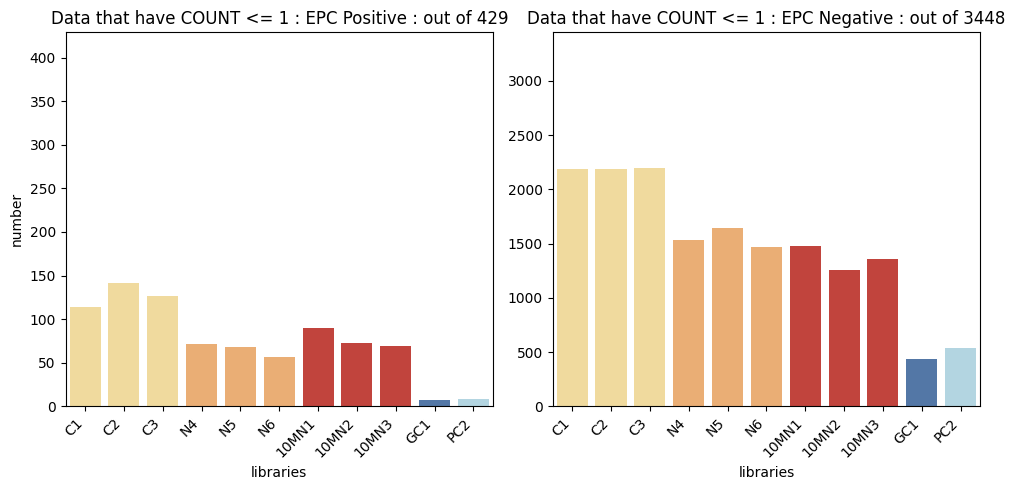

In [51]:
# FROM COUNT PROFILE, HOW MANY DATA THAT HAVE CAGE/GROCAP/PROCAP <= 1 

# Calculate column sums
pos_colsum = pos_mask.sum(axis=0)
neg_colsum = neg_mask.sum(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot positive barplot
sns.barplot(x=pos_colsum.index, y=pos_colsum.values, palette=palette, ax=ax1)
ax1.set_title('Data that have COUNT <= 1 : EPC Positive : out of ' + str(len(pos_mask)))
ax1.set_xlabel('libraries')
ax1.set_ylabel('number')
ax1.set_ylim(0, P)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# Plot negative barplot
sns.barplot(x=neg_colsum.index, y=neg_colsum.values, palette=palette, ax=ax2)
ax2.set_title('Data that have COUNT <= 1 : EPC Negative : out of ' + str(len(neg_mask)))
ax2.set_xlabel('libraries')
#ax2.set_ylabel('number')
ax2.set_ylim(0, N)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [52]:
#### PREDICTION ####

In [53]:
# confusion matrix on each object

def proba_confusion_matrix(df_pos, df_neg, threshold, P, N, mask):
    
    predpos = df_pos >= threshold
    TP = predpos.sum(axis=0)
    FN = P - TP
    
    cageneg_pos = df_pos == mask
    FN_cage = cageneg_pos.sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg < threshold
    TN = predneg.sum(axis=0)  
    FP = N - TN
    
    cageneg_neg = df_neg == mask
    TN_cage = cageneg_neg.sum(axis=0)
    TN_pred = TN - TN_cage
    
    
    
    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred}
                              )
    
    return confusion


In [54]:
def precaision_recall(confusion):
    precision = confusion['TP'] / (confusion['TP'] + confusion['FP'])
    recall = confusion['TP'] / (confusion['TP'] + confusion['FN'])
    df = pd.DataFrame({'precision':precision,
                       'recall':recall})
    return(df)

In [55]:
def plot_confusion(confusion, save):
    confusion_melted = pd.melt(confusion, id_vars='Lib', var_name='Metric', value_name='Count')
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
    axes = axes.flatten()
    ylimit = [P, P, N, N, P, P, N, N]
    for i, column in enumerate(confusion.columns[1:]):  # Exclude the first column ('Lib')
        sns.barplot(x='Lib', y=column, data=confusion, ax=axes[i], palette=palette)
        axes[i].set_title(f'{column}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, ylimit[i])
    plt.tight_layout()
    if save != False:
        plt.savefig(save + '.pdf')
    plt.show()

In [56]:
def wrap_cfs_pr_plot(df_pos, df_neg, threshole, P, N, mask, save=False):
    cfs = proba_confusion_matrix(df_pos, df_neg, threshole, P, N, mask)
    pr = precaision_recall(cfs)
    plot_confusion(cfs, save)
    return(cfs, pr)

In [57]:
#### VARY PROBABILITY THRESHOLD ####

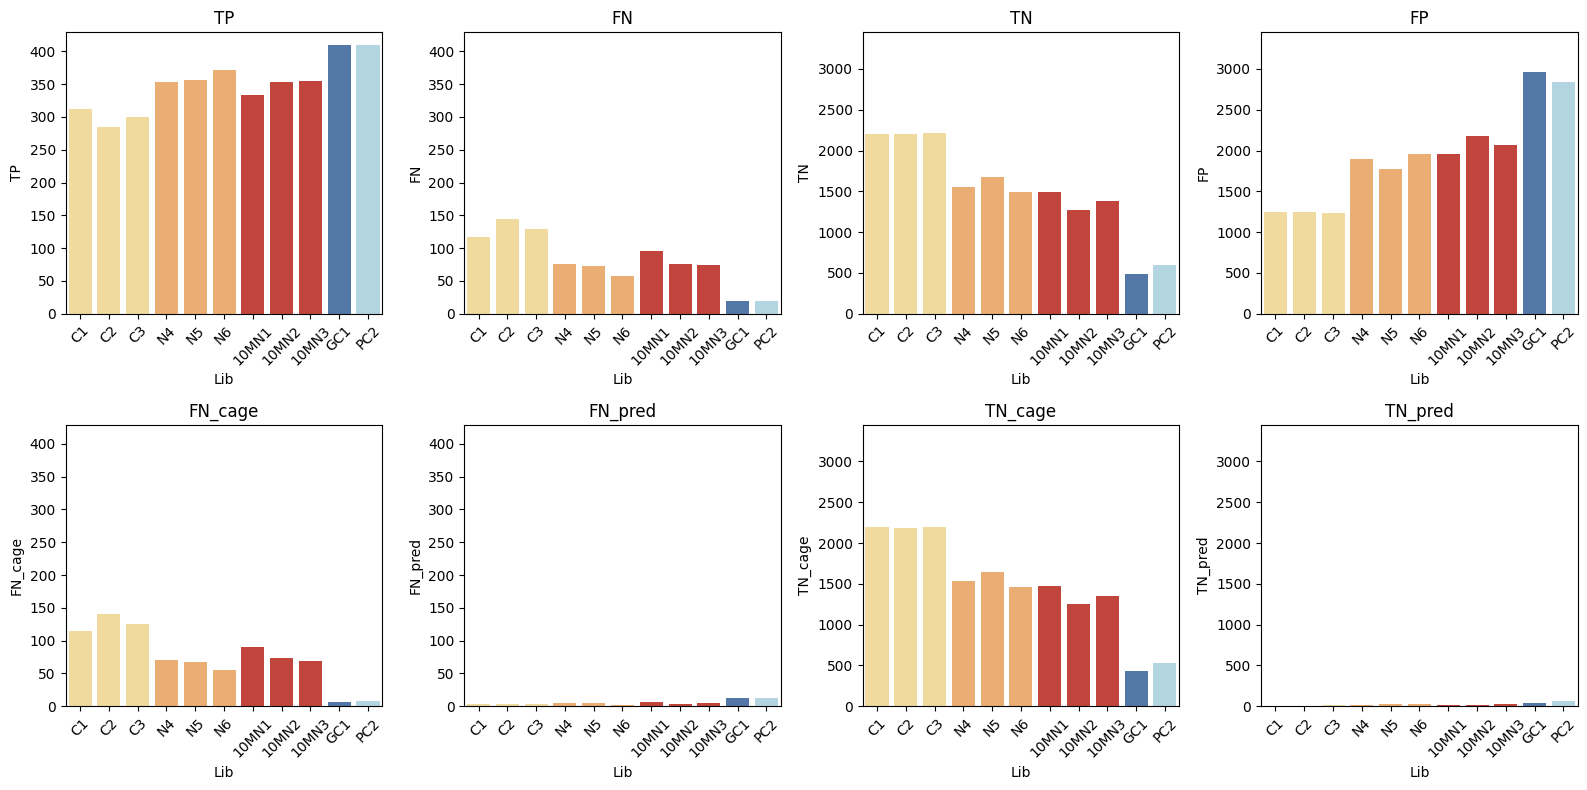

In [58]:
#### TRESHOLE=0.3 ####
cfs_yproba_maskm1_030, pr_yproba_maskm1_030 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.3, P, N, -1)

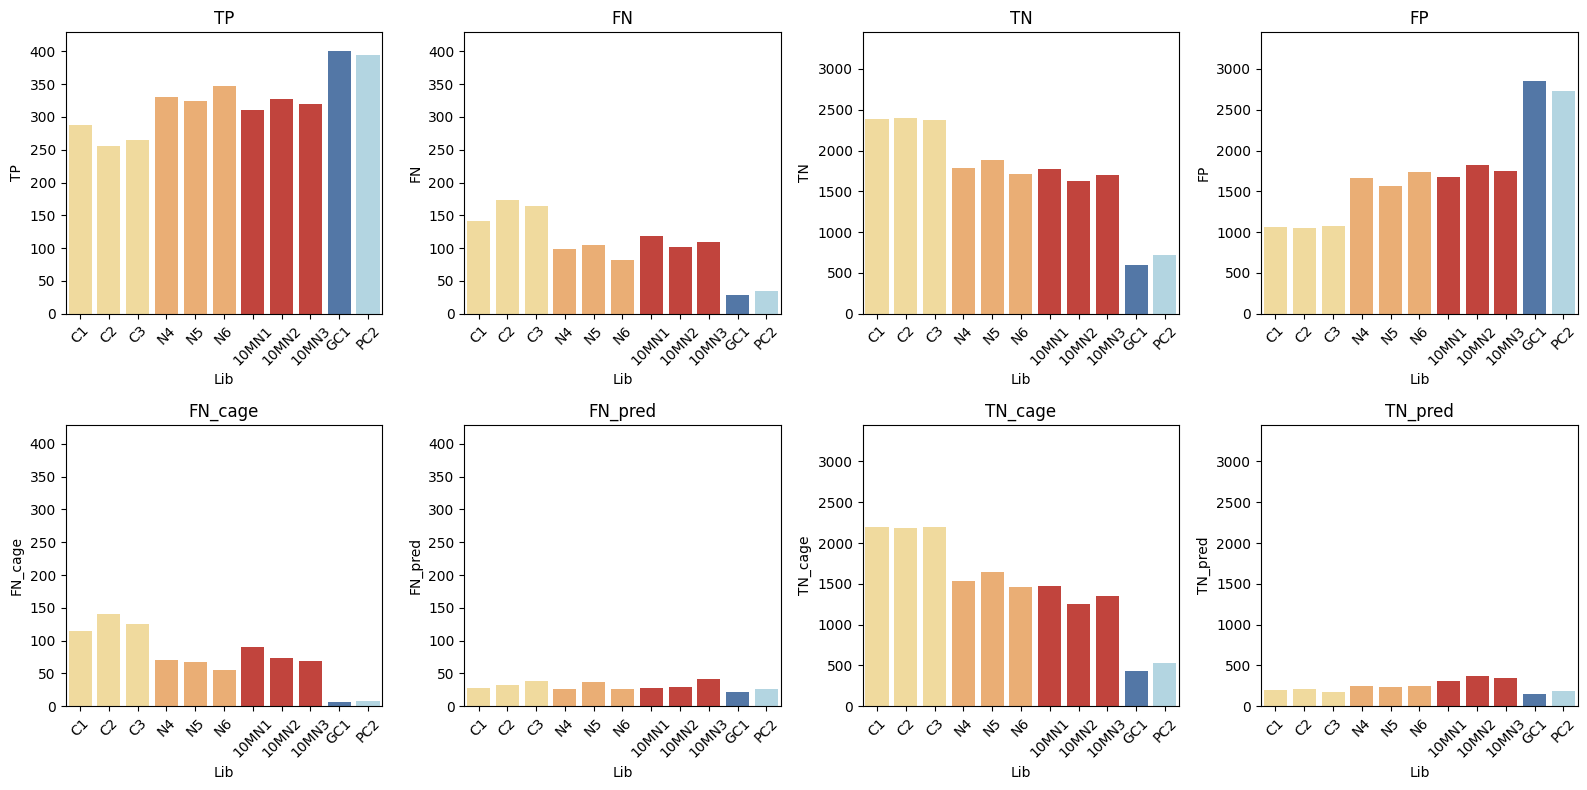

In [59]:
#### TRESHOLE=0.5 ####
cfs_yproba_maskm1_050, pr_yproba_maskm1_050 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.5, P, N, -1, 
                                                               save='4.EPC.confusionMatrix.barplot.prediction.050.repSub')

In [60]:
pr_yproba_maskm1_050.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.213066,0.195402,0.198057,0.165832,0.171701,0.166827,0.156991,0.152306,0.154181,0.123157,0.126400
recall,0.668998,0.594406,0.617716,0.771562,0.755245,0.808858,0.724942,0.762238,0.743590,0.934732,0.920746


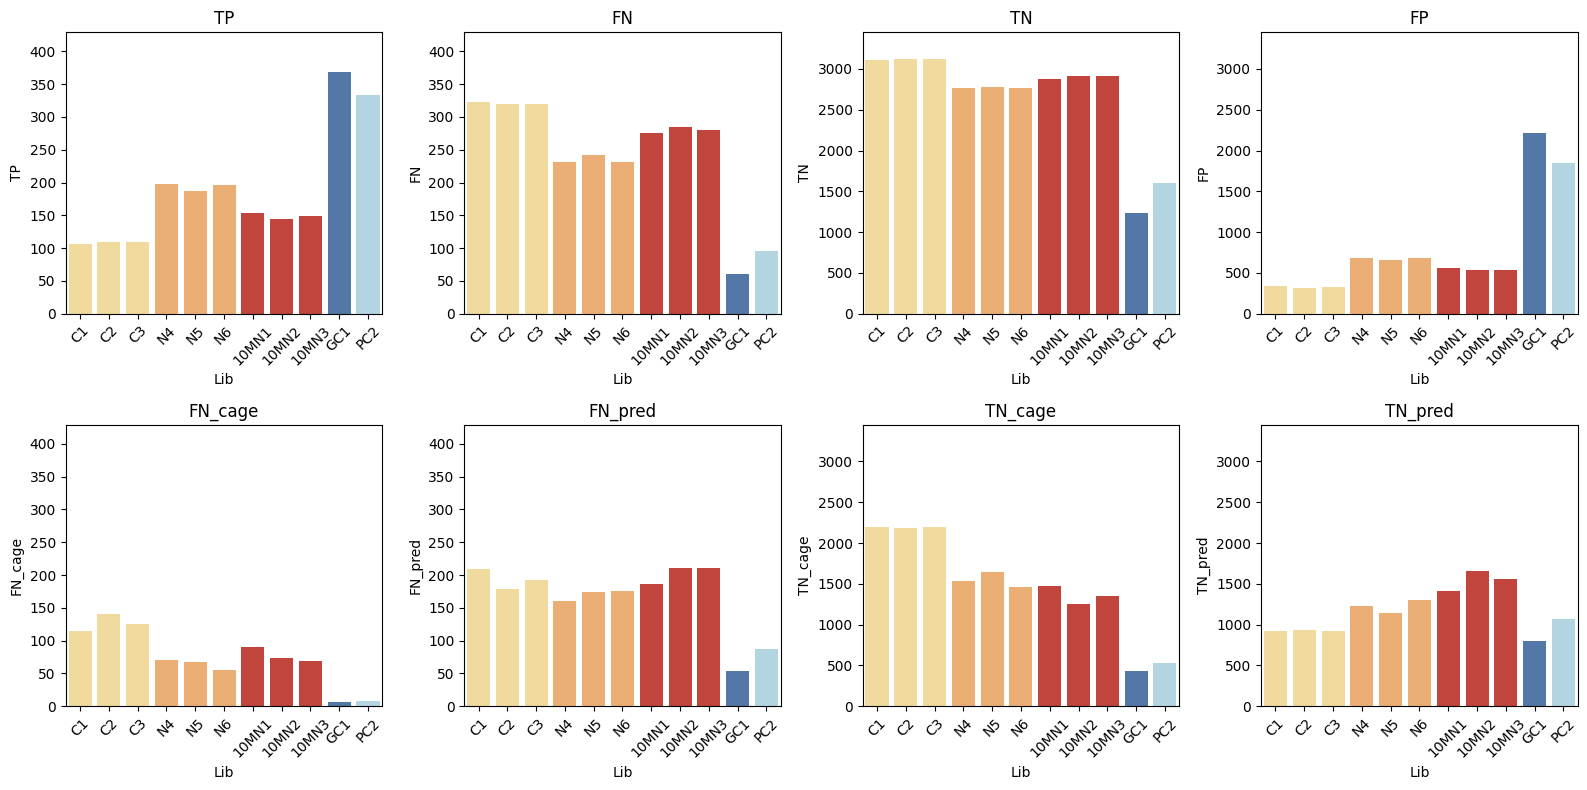

In [61]:
#### TRESHOLE=0.7 ####
cfs_yproba_maskm1_070, pr_yproba_maskm1_070 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.7, P, N, -1)

In [62]:
#### ROC AND AUCROC###

In [63]:
# Plot ROC Curve
def plot_roc_df(y_true, yproba, samples, save=False):
    plt.figure(figsize=(10, 5))
    for i in samples:
        fpr, tpr, _ = roc_curve(y_true, yproba[i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})', color=colors[i])
        
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    if save != False:
        plt.savefig(save + '.pdf')
    plt.show()
    #print(_)

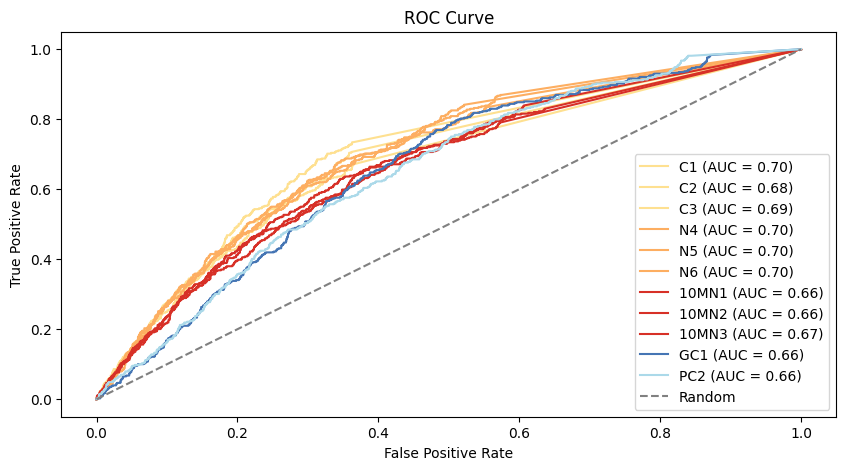

In [64]:
plot_roc_df(y_true, yproba_maskm1, prefer_order, save='4.EPC.ROC.curve.prediction.repSub')

In [65]:
#### PR CURVE AND AUCPR ####

In [66]:
# Plot PR Curve

def plot_pr_df(y_true, yproba, samples, save=False):
    plt.figure(figsize=(10, 5))
    
    for i in samples:
        precision, recall, _ = precision_recall_curve(y_true, yproba[i])
        #print(precision)
        #print(recall)
        area_under_curve = auc(recall, precision)
        #print(area_under_curve)
        plt.plot(recall, precision, label=f'{i} (AUC = {area_under_curve:.2f})', color=colors[i])
        #avg_precision = average_precision_score(y_true, yproba[i])
        #plt.plot(recall, precision, label=f'{i} (AP = {avg_precision:.2f})', color=colors[i])
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    if save != False:
        plt.savefig(save + '.pdf')
    plt.show()

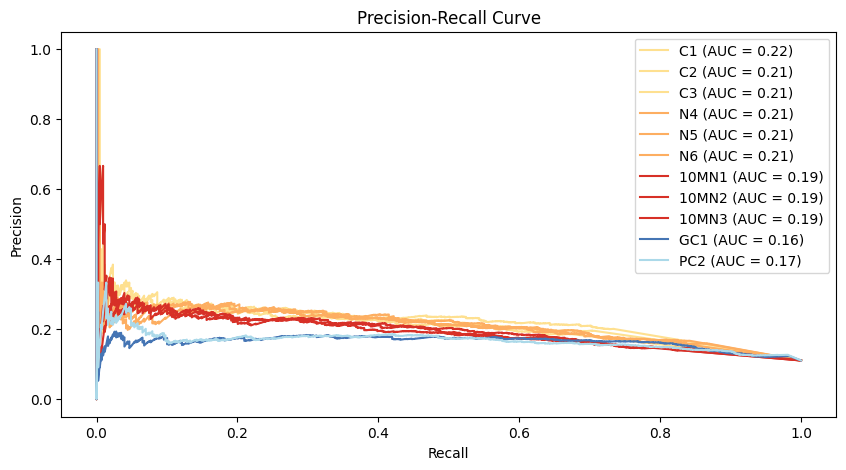

In [67]:
plot_pr_df(y_true, yproba_maskm1, prefer_order, save='4.EPC.PR.curve.prediction.repSub')

In [68]:
#### DIVERGENT LOCI ####

In [69]:
def dl_confusion_matrix(df_pos, df_neg, threshole, P, N, mask, save=False):
    
    predpos = df_pos < threshole
    TP = predpos.sum(axis=0)
    FN = P - TP
    
    cageneg_pos = df_pos == mask
    FN_cage = cageneg_pos.sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg >= threshole
    TN = predneg.sum(axis=0)
    FP = N - TN
    
    cageneg_neg = df_neg == mask
    TN_cage = cageneg_neg.sum(axis=0)
    TN_pred = TN - TN_cage
    
    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred})
    
    return(confusion)

In [70]:
def wrap_cfs_pr_plot_dl(df_pos, df_neg, threshole, P, N, mask, save=False):
    cfs = dl_confusion_matrix(df_pos, df_neg, threshole, P, N, mask)
    pr = precaision_recall(cfs)
    plot_confusion(cfs, save)
    return(cfs, pr)

In [71]:
#### VARY ABS DIRECTIONALITY THRESHOLD : 0.7, 0.8, 0.9 ####

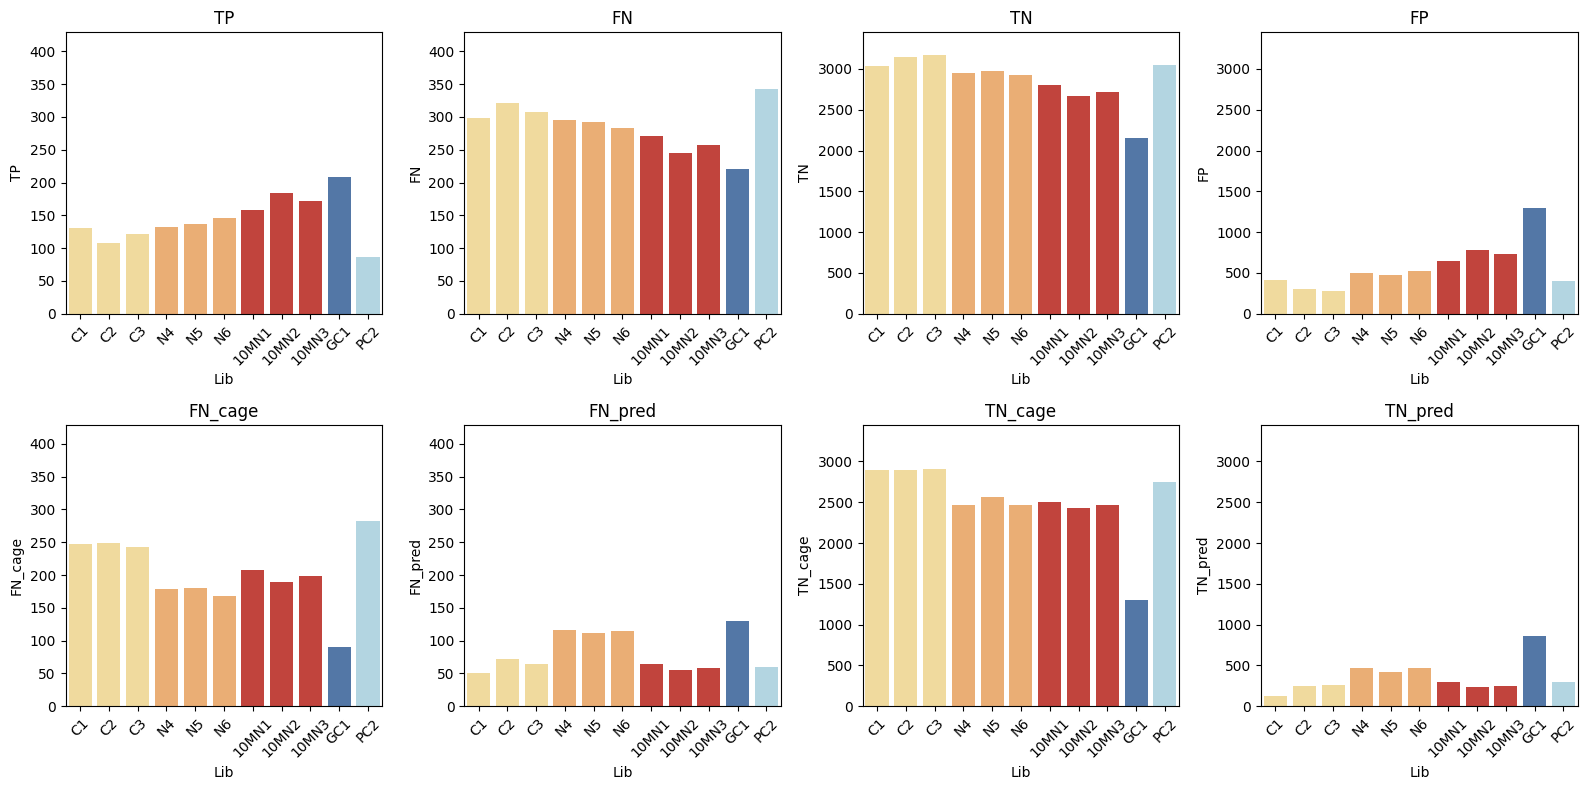

In [72]:
#### ABS DIRECTIONALITY < 0.7 ####
cfs_dl_070, pr_dl_070 = wrap_cfs_pr_plot_dl(pos_dl_absdir_mask1, neg_dl_absdir_mask1, 0.7, P, N, 1.1)

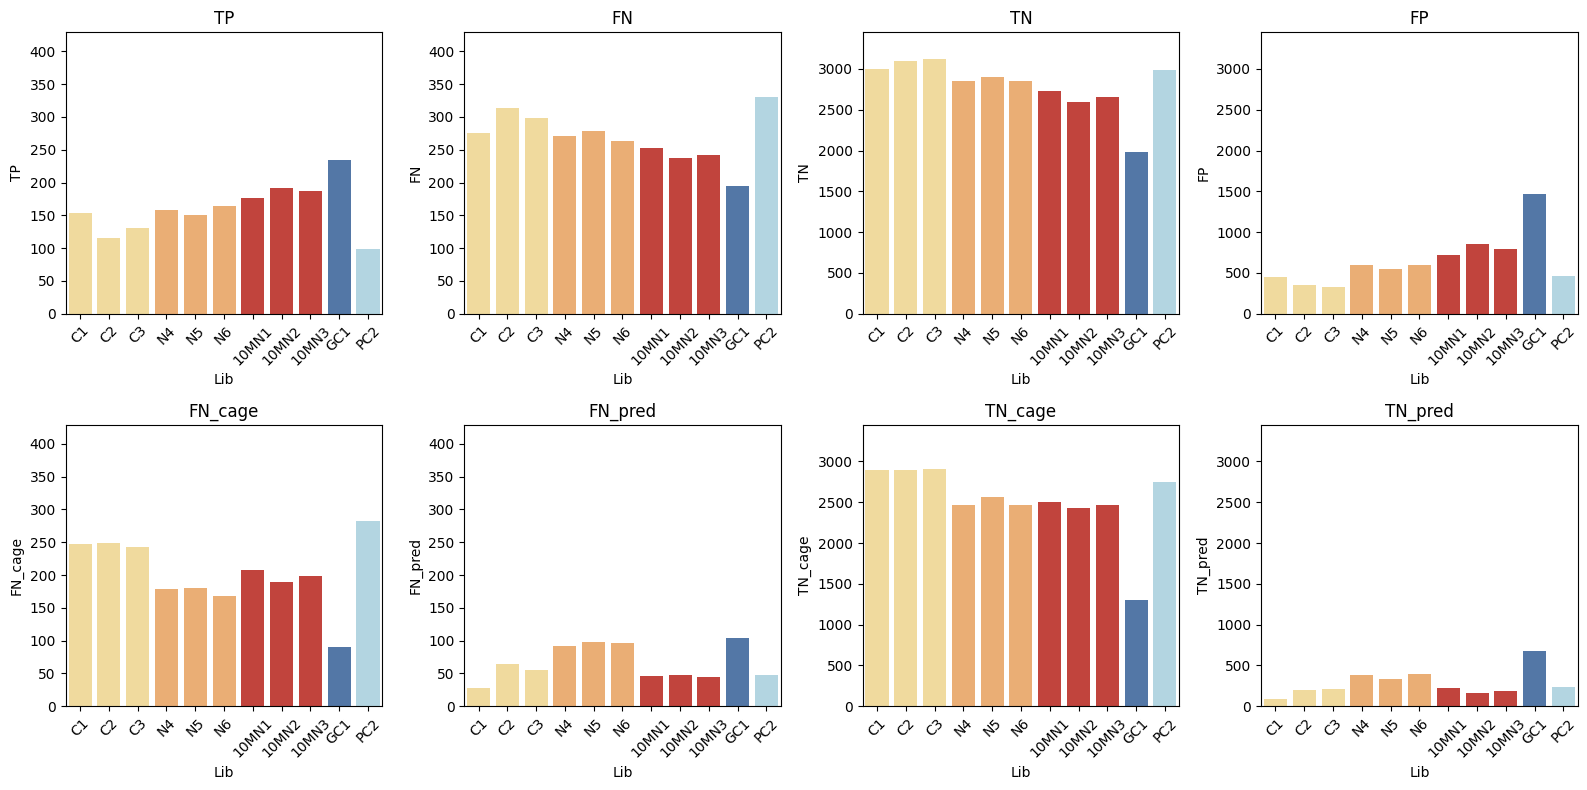

In [73]:
#### ABS DIRECTIONALITY < 0.8 ####
cfs_dl_080, pr_dl_080 = wrap_cfs_pr_plot_dl(pos_dl_absdir_mask1, neg_dl_absdir_mask1, 0.8, P, N, 1.1, 
                                            save='4.EPC.confusionMatrix.barplot.DL.080.repSub')

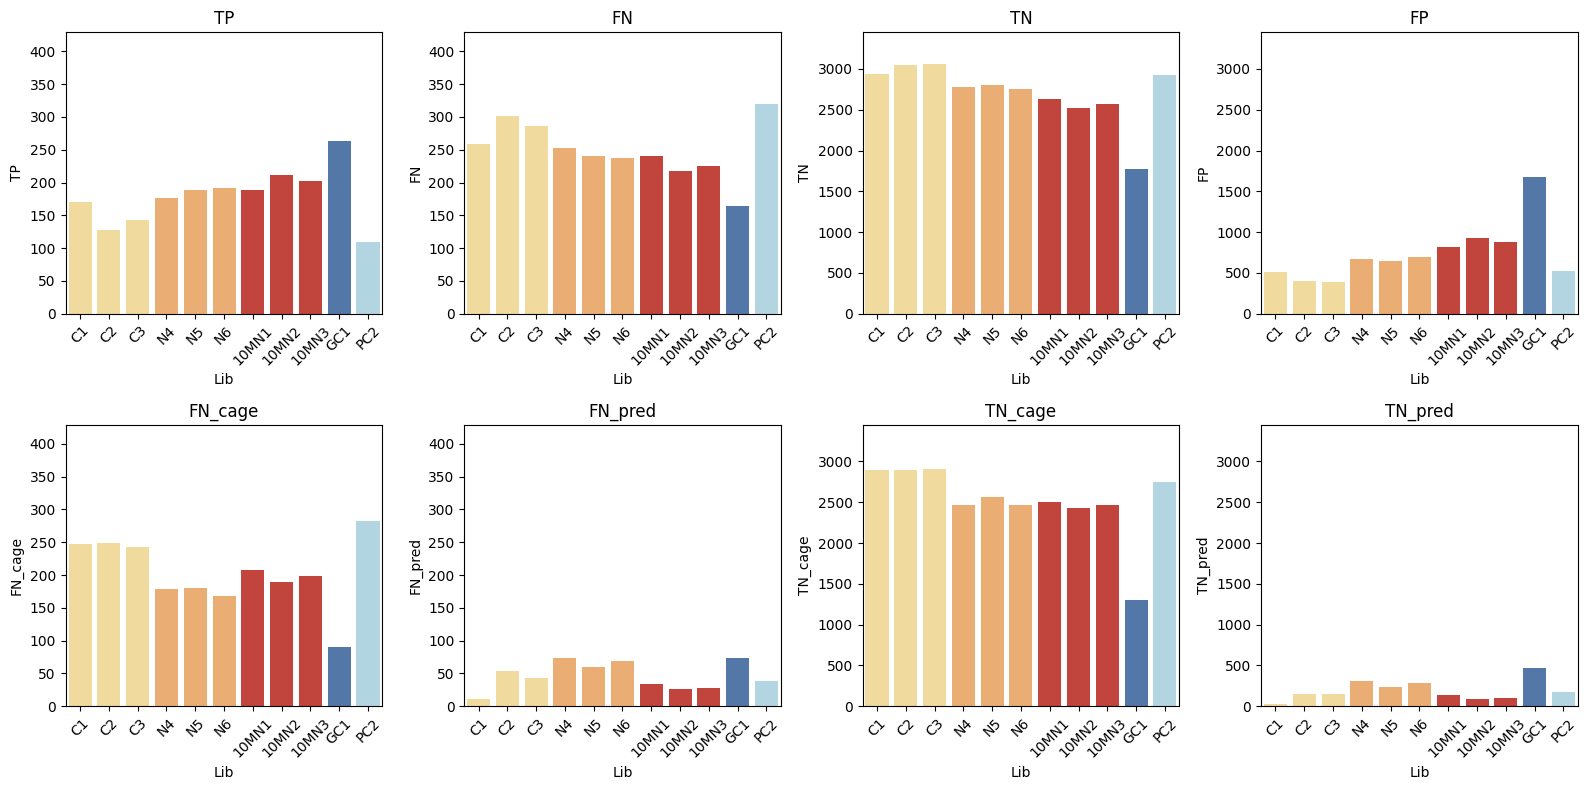

In [74]:
#### ABS DIRECTIONALITY < 0.9 ####
cfs_dl_090, pr_dl_090 = wrap_cfs_pr_plot_dl(pos_dl_absdir_mask1, neg_dl_absdir_mask1, 0.9, P, N, 1.1)

In [75]:
#### ROC CURVE AND AUCROC ####

In [76]:
# for dl, roc can be set param pos_label=0
# however, it doesn't work for pr
# set reverse label instead [0 for positive, 1 for negative]

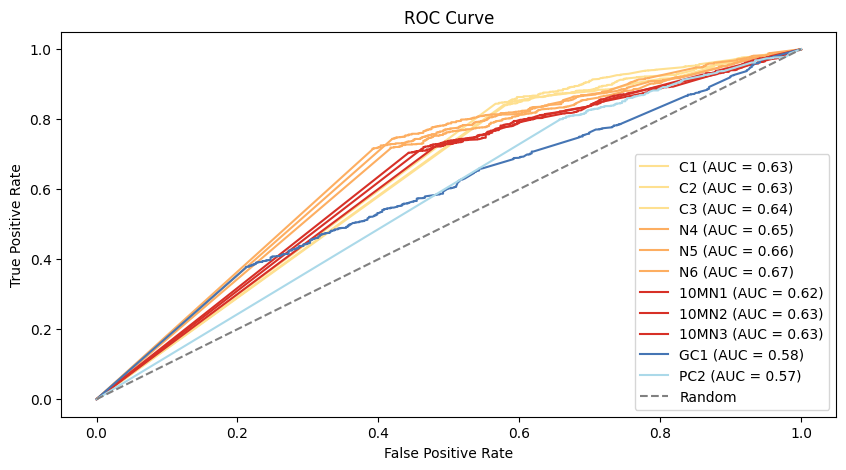

In [77]:
plot_roc_df(y_true_reverse, dl_absdir_mask1, prefer_order)

In [78]:
#### PR CURVE AND AUCPR ####

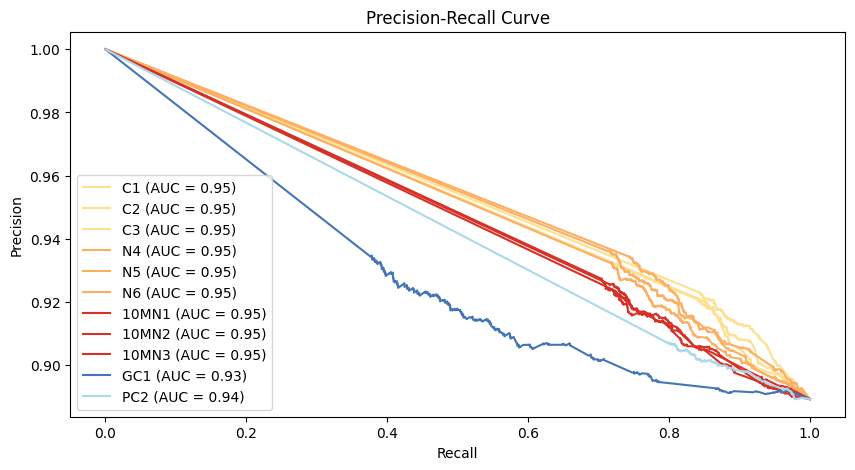

In [79]:
plot_pr_df(y_true_reverse, dl_absdir_mask1, prefer_order)

In [80]:
#### Bidir X Prediction ####

In [81]:
dlpos = pos_dl_absdir_mask1 < 0.8
predpos = pos_yproba_maskm1 >= 0.5

dlneg = neg_dl_absdir_mask1 < 0.8
predneg = neg_yproba_maskm1 >= 0.5

In [82]:
def counting_table(dl, pred):
    df = pd.DataFrame(index=dl.index, columns=dl.columns)
    df[:] = np.where((dl == True) & (pred == True), 'DL=TRUE & PRED=TRUE (T-T)',
                     np.where((dl == True) & (pred == False), 'DL=TRUE & PRED=FALSE (T-F)',
                              np.where((dl == False) & (pred == True), 'DL=FALSE & PRED=TRUE (F-T)', 'DL=FALSE & PRED=FALSE (F-F)')))
    return(df)

In [83]:
def count_occurrences(column):
    return column.value_counts()

In [84]:
ctpos = counting_table(dlpos, predpos)
result_pos = ctpos.apply(count_occurrences)
result_pos

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
DL=FALSE & PRED=FALSE (F-F),99,134,120,68,70,56,72,60,74,16,25
DL=FALSE & PRED=TRUE (F-T),177,180,178,203,208,208,181,177,168,179,305
DL=TRUE & PRED=FALSE (T-F),43,40,44,30,35,26,46,42,36,12,9
DL=TRUE & PRED=TRUE (T-T),110,75,87,128,116,139,130,150,151,222,90


In [85]:
ctneg = counting_table(dlneg, predneg)
result_neg = ctneg.apply(count_occurrences)
result_neg

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
DL=FALSE & PRED=FALSE (F-F),2112,2195,2172,1528,1635,1465,1447,1264,1338,368,629
DL=FALSE & PRED=TRUE (F-T),881,903,950,1328,1267,1390,1277,1328,1314,1609,2360
DL=TRUE & PRED=FALSE (T-F),276,203,203,255,250,250,331,364,360,225,89
DL=TRUE & PRED=TRUE (T-T),179,147,123,337,296,343,393,492,436,1246,370


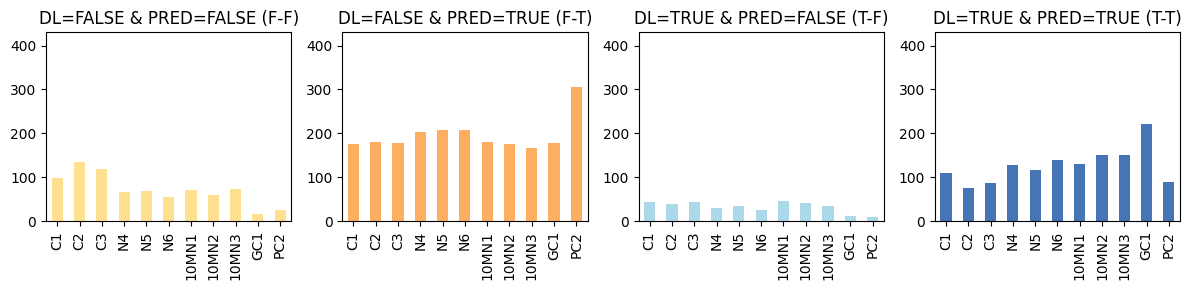

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

palettes = ["#fee090", "#fdae61", "#abd9e9", "#4575b4"]

# Convert the dictionaries to dataframes
df_pos = pd.DataFrame(result_pos)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Flatten the axes for easy indexing
axes = axes.flatten()

# Plot data for each category
for i, (category, ax) in enumerate(zip(df_pos.index, axes)):
    df_pos.loc[category].plot(kind='bar', ax=ax, color=palettes[i])
    ax.set_title(category)
    ax.set_ylim(0, 430)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

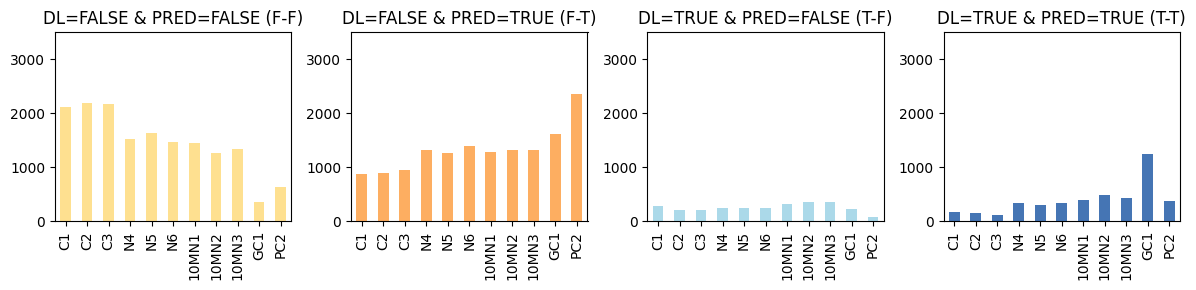

In [87]:
# Convert the dictionaries to dataframes
df_neg = pd.DataFrame(result_neg)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Flatten the axes for easy indexing
axes = axes.flatten()

# Plot data for each category
for i, (category, ax) in enumerate(zip(df_neg.index, axes)):
    df_neg.loc[category].plot(kind='bar', ax=ax, color=palettes[i])
    ax.set_title(category)
    ax.set_ylim(0, 3500)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [88]:
#import plotly.express as px

In [89]:
#pos_csv neg_dl_mask1 neg_yproba_maskm1

In [90]:
#neg_csv_slt =neg_csv[['txType', 'ovl.DHS', 'ovl.eQTL0.5']]

In [91]:
'''
import pandas as pd

df = pd.DataFrame(neg_csv_slt)

# Create an empty dictionary to store mappings
mappings = {}

# Factorize each column and store mappings
for col in df.columns:
    factorized, mapping = pd.factorize(df[col])
    mappings[col] = dict(zip(mapping, range(1, len(mapping) + 1)))  # Create a mapping dictionary
    df[col] = factorized + 1  # Factorize and add 1 to start from 1 instead of 0

# Display the modified DataFrame
print("Modified DataFrame:")
print(df)

# Display the mappings
print("\nMappings:")
for col, mapping in mappings.items():
    print(f"{col}: {mapping}")
'''

'\nimport pandas as pd\n\ndf = pd.DataFrame(neg_csv_slt)\n\n# Create an empty dictionary to store mappings\nmappings = {}\n\n# Factorize each column and store mappings\nfor col in df.columns:\n    factorized, mapping = pd.factorize(df[col])\n    mappings[col] = dict(zip(mapping, range(1, len(mapping) + 1)))  # Create a mapping dictionary\n    df[col] = factorized + 1  # Factorize and add 1 to start from 1 instead of 0\n\n# Display the modified DataFrame\nprint("Modified DataFrame:")\nprint(df)\n\n# Display the mappings\nprint("\nMappings:")\nfor col, mapping in mappings.items():\n    print(f"{col}: {mapping}")\n'

In [92]:
'''
neg_csv_slt['dl_N'] = neg_dl_mask1['N']
neg_csv_slt['pred_N'] = neg_yproba_maskm1['N']
neg_csv_slt
'''

"\nneg_csv_slt['dl_N'] = neg_dl_mask1['N']\nneg_csv_slt['pred_N'] = neg_yproba_maskm1['N']\nneg_csv_slt\n"

In [93]:
'''
# Create the chart:
fig = px.parallel_coordinates(
    df, 
    color="pred_N", 
    labels={"dl_N":"dl_N", "pred_N":"pred_N", "txType": "txType","ovl.DHS": "ovl.DHS", "ovl.eQTL0.5h": "ovl.eQTL0.5", },)
    #color_continuous_scale=px.colors.diverging.Tealrose,
    #color_continuous_midpoint=2)

# Hide the color scale that is useless in this case
#fig.update_layout(coloraxis_showscale=False)

# Show the plot
fig.show()
'''

'\n# Create the chart:\nfig = px.parallel_coordinates(\n    df, \n    color="pred_N", \n    labels={"dl_N":"dl_N", "pred_N":"pred_N", "txType": "txType","ovl.DHS": "ovl.DHS", "ovl.eQTL0.5h": "ovl.eQTL0.5", },)\n    #color_continuous_scale=px.colors.diverging.Tealrose,\n    #color_continuous_midpoint=2)\n\n# Hide the color scale that is useless in this case\n#fig.update_layout(coloraxis_showscale=False)\n\n# Show the plot\nfig.show()\n'